In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
from viz_style import apply_style
apply_style()
import matplotlib.pyplot as plt


## 1. Demotion characteristics by stage

In [2]:
from MixedEffectsModeling.validation.pool_vs_individual_sweep import load_hc
Xs, Y, batch, gene_names = load_hc()
gmap = {g: i for i, g in enumerate(gene_names)}
summ = pd.read_csv(config.ENGINE_MIXED_DIR / "training_summary.csv")
summ = summ[summ.gene.isin(gmap)]
cols = summ.gene.map(gmap).values
mean_c, max_c = Y[:, cols].mean(0), Y[:, cols].max(0)
zero_frac = (Y[:, cols] == 0).mean(0)
summ = summ.assign(mean_hc=mean_c, max_hc=max_c, zero_frac=zero_frac, max_over_mean=max_c / np.maximum(mean_c, 1e-9))
table = summ.groupby("stage").agg(n=("gene", "size"), nz_med=("nz", "median"),
    mean_hc_med=("mean_hc", "median"), zero_frac_med=("zero_frac", "median"),
    max_over_mean_med=("max_over_mean", "median"), max_over_mean_p90=("max_over_mean", lambda x: x.quantile(0.9)))
table


,n,nz_med,mean_hc_med,zero_frac_med,max_over_mean_med,max_over_mean_p90
stage,,,,,,
intercept,877,5.0,0.023088,0.992785,297.000000,673.312292
nb_fixed,135,13.0,0.070707,0.981241,206.684211,498.283648
nbi,19080,547.0,32.756133,0.210678,27.328441,176.588264
nbi_disp_intercept,5,18.0,0.085137,0.974026,129.203390,336.270686


/tmp/ipykernel_586569/823561369.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([summ[summ.stage == s]["max_over_mean"].values for s in stages], labels=stages, showfliers=False)


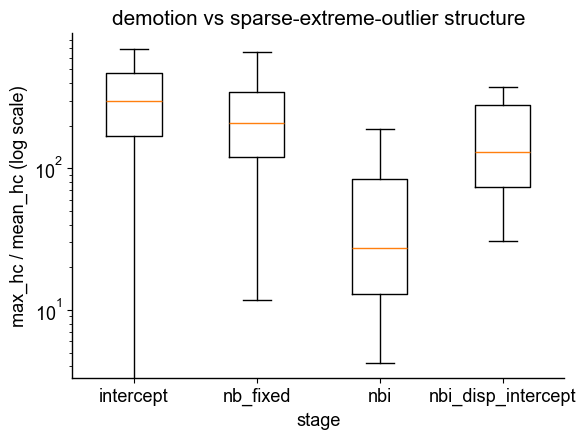

In [3]:
stages = table.index.tolist()
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot([summ[summ.stage == s]["max_over_mean"].values for s in stages], labels=stages, showfliers=False)
ax.set_yscale("log")
ax.set(xlabel="stage", ylabel="max_hc / mean_hc (log scale)", title="demotion vs sparse-extreme-outlier structure")
fig.tight_layout()
plt.show()


## 2. beta_explode_thr calibration (Q3)

In [4]:
uc = pd.read_csv(config.THRESHOLD_SWEEP_DIR / "full_cascade_unconstrained.csv")
nbi = uc[uc.stage == "nbi"].copy()
mu_cols = [f"mu_coef_{i}" for i in range(1, 11)]
mu_slopes = nbi[mu_cols].values.ravel()
mu_slopes = mu_slopes[~np.isnan(mu_slopes)]
quantiles = [0.5, 0.9, 0.95, 0.99, 0.999, 0.9999]
q_table = pd.Series(np.quantile(np.abs(mu_slopes), quantiles), index=quantiles, name="abs_mu_slope_quantile")
q_table.loc["max"] = np.abs(mu_slopes).max()
q_table


0.5       0.165024
0.9       0.982330
0.95      1.106273
0.99      1.641823
0.999     2.591273
0.9999    2.937702
max       2.988970
Name: abs_mu_slope_quantile, dtype: float64

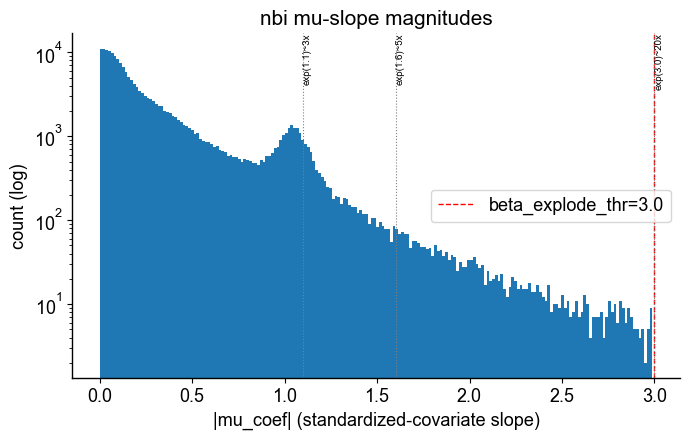

In [5]:
BETA_EXPLODE_THR = config.SPIKE_PARAMS["beta_explode_thr"]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(np.abs(mu_slopes), bins=200, log=True)
ax.axvline(BETA_EXPLODE_THR, color="red", ls="--", label=f"beta_explode_thr={BETA_EXPLODE_THR}")
for slope, fold in [(1.1, "3x"), (1.6, "5x"), (3.0, "20x")]:
    ax.axvline(slope, color="gray", ls=":", lw=0.8)
    ax.annotate(f"exp({slope})~{fold}", xy=(slope, ax.get_ylim()[1]), rotation=90, fontsize=7, va="top")
ax.set(xlabel="|mu_coef| (standardized-covariate slope)", ylabel="count (log)", title="nbi mu-slope magnitudes")
ax.legend()
fig.tight_layout()
plt.show()


## 3. Dispersion shrinkage prior effect (Q4)

In [6]:
disp_cols = [f"disp_coef_{i}" for i in range(1, 11)]
disp_slopes = nbi[disp_cols].values.ravel()
disp_slopes = disp_slopes[~np.isnan(disp_slopes)]
q_table_disp = pd.Series(np.quantile(np.abs(disp_slopes), quantiles), index=quantiles, name="abs_disp_slope_quantile")
q_table_disp.loc["max"] = np.abs(disp_slopes).max()
q_table_disp


0.5       0.045688
0.9       0.195297
0.95      0.276642
0.99      0.391271
0.999     0.454459
0.9999    0.490958
max       0.517985
Name: abs_disp_slope_quantile, dtype: float64

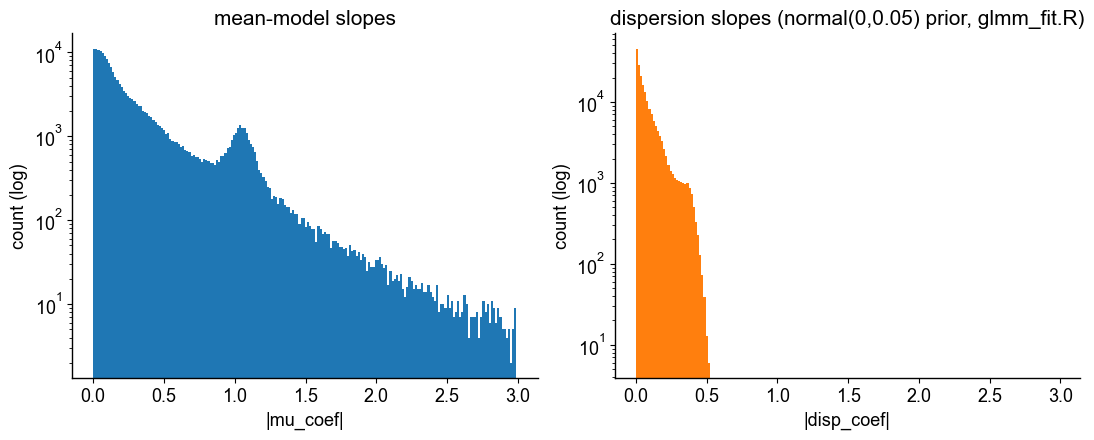

median |mu_coef| = 0.1650238820834795  median |disp_coef| = 0.04568791808575045


In [7]:
shared_xmax = max(np.abs(mu_slopes).max(), np.abs(disp_slopes).max())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
axes[0].hist(np.abs(mu_slopes), bins=200, log=True, range=(0, shared_xmax))
axes[0].set(xlabel="|mu_coef|", ylabel="count (log)", title="mean-model slopes")
axes[1].hist(np.abs(disp_slopes), bins=200, log=True, range=(0, shared_xmax), color="tab:orange")
axes[1].set(xlabel="|disp_coef|", ylabel="count (log)", title="dispersion slopes (normal(0,0.05) prior, glmm_fit.R)")
fig.tight_layout()
plt.show()
print("median |mu_coef| =", np.median(np.abs(mu_slopes)), " median |disp_coef| =", np.median(np.abs(disp_slopes)))


## 4. nb_fixed dispersion trend mismatch (Q2, main finding)

In [8]:
from MixedEffectsModeling.core.dispersion_trend import load_trend
mean_hc = Y.mean(0)
nz = (Y > 0).sum(0)
nbi2 = uc[uc.stage == "nbi"].copy()
nbi2 = nbi2[nbi2.gene.isin(gmap)]
nbi2["col"] = nbi2.gene.map(gmap)
nbi2["mean_hc"] = mean_hc[nbi2["col"].values]
nbi2["nz"] = nz[nbi2["col"].values]
nbi2["alpha_nbi_baseline"] = np.exp(-nbi2["disp_coef_0"])
alpha_of = load_trend()
nbi2["alpha_trend"] = nbi2["mean_hc"].apply(alpha_of)
nbi2["log_ratio"] = np.log(nbi2["alpha_nbi_baseline"] / nbi2["alpha_trend"])
bins = [0, 15, 30, 50, 75, 100, 150, 300, 700]
nbi2["nz_bin"] = pd.cut(nbi2["nz"], bins)
binned = nbi2.groupby("nz_bin", observed=True)["log_ratio"].agg(["median", "std", "count"])
binned


,median,std,count
nz_bin,,,
"(0, 15]",-0.529848,0.983635,372
"(15, 30]",-0.496664,0.742520,695
"(30, 50]",-0.708620,0.618008,806
"(50, 75]",-0.845665,0.486452,848
"(75, 100]",-0.997112,0.482927,681
"(100, 150]",-1.092194,0.437376,1004
"(150, 300]",-1.201319,0.450350,2000
"(300, 700]",-1.797597,0.614442,12674


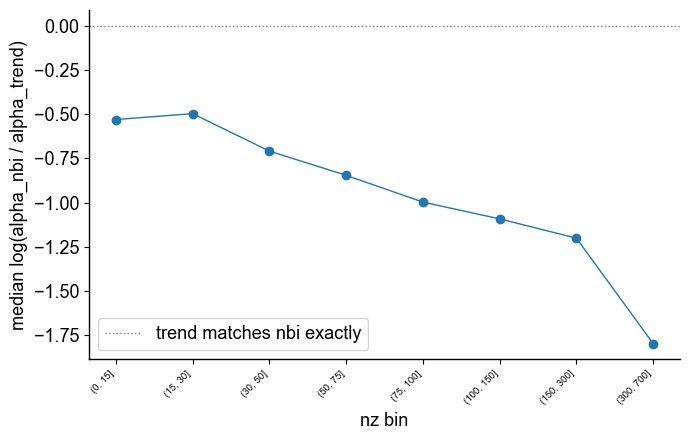

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(binned))
ax.plot(x, binned["median"], "-o")
ax.axhline(0, ls=":", color="gray", label="trend matches nbi exactly")
ax.set_xticks(x); ax.set_xticklabels([str(b) for b in binned.index], rotation=45, ha="right", fontsize=7)
ax.set(xlabel="nz bin", ylabel="median log(alpha_nbi / alpha_trend)")
ax.legend()
fig.tight_layout()
plt.show()


In [10]:
gld = pd.read_csv(config.THRESHOLD_SWEEP_DIR / "gene_level_diagnostics.csv")
summ2 = pd.read_csv(config.ENGINE_MIXED_DIR / "training_summary.csv")[["gene", "stage"]]
ind = gld[gld.fit == "individual"].merge(summ2, on="gene", how="left")
ind["std_ratio"] = ind["pred_std"] / ind["obs_std"]
stage_table = ind.groupby("stage").agg(n=("gene", "size"), median_std_ratio=("std_ratio", "median"),
    mean_z=("mean_z", "median"), std_z=("std_z", "median"))
stage_table


,n,median_std_ratio,mean_z,std_z
stage,,,,
intercept,2051,0.888976,0.000837,1.006176
nb_fixed,389,5.990915,0.015234,1.028829
nbi,8901,2.308136,0.010716,1.036802
nbi_disp_intercept,12,53.813283,0.003534,1.008496


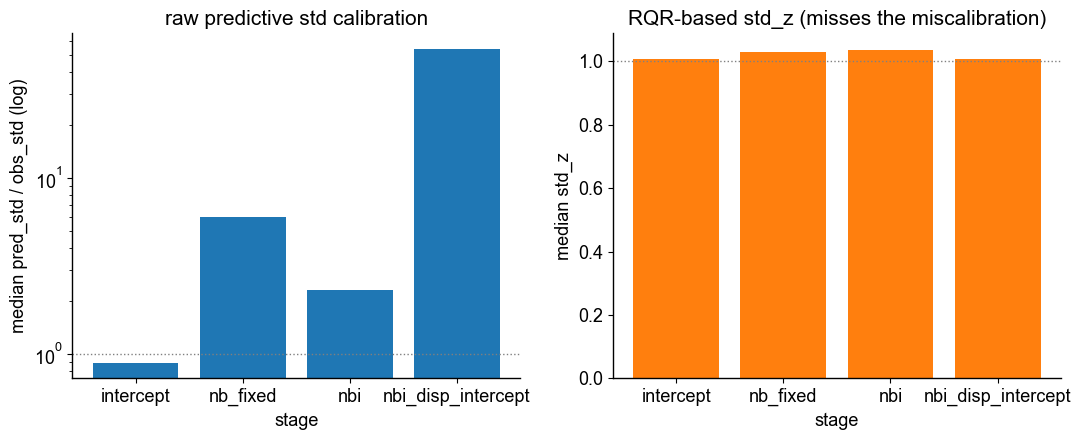

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(stage_table.index.astype(str), stage_table["median_std_ratio"])
axes[0].set_yscale("log")
axes[0].axhline(1.0, ls=":", color="gray")
axes[0].set(xlabel="stage", ylabel="median pred_std / obs_std (log)", title="raw predictive std calibration")
axes[1].bar(stage_table.index.astype(str), stage_table["std_z"], color="tab:orange")
axes[1].axhline(1.0, ls=":", color="gray")
axes[1].set(xlabel="stage", ylabel="median std_z", title="RQR-based std_z (misses the miscalibration)")
fig.tight_layout()
plt.show()


## 5. nz vs stage/tau2 composition (glmm full unconstrained)

In [12]:
df = pd.read_csv(config.THRESHOLD_SWEEP_DIR / "full_cascade_unconstrained.csv")
nz_map_full = dict(zip(gene_names, (Y > 0).sum(0)))  # reuse Y/gene_names from Section 1, not a stale /tmp file
df["nz"] = df["gene"].map(nz_map_full)
df["nz_bin"] = pd.cut(df["nz"], bins=[0, 3, 7, 15, 30, 50, 100, np.inf])

nz_stage_summary = df.groupby("nz_bin", observed=True).agg(
    n_genes=("gene", "size"), ok_rate=("ok", "mean"),
    tau2_median=("tau2", "median"),
    pct_nbi=("stage", lambda s: (s == "nbi").mean()),
    pct_intercept=("stage", lambda s: (s == "intercept").mean()),
)
nz_stage_summary.round(3)


,n_genes,ok_rate,tau2_median,pct_nbi,pct_intercept
nz_bin,,,,,
"(0.0, 3.0]",242,0.306,46.948,0.008,0.979
"(3.0, 7.0]",281,0.612,1.598,0.253,0.648
"(7.0, 15.0]",570,0.860,0.316,0.525,0.395
"(15.0, 30.0]",824,0.984,0.000,0.843,0.109
"(30.0, 50.0]",844,0.998,0.000,0.955,0.024
"(50.0, 100.0]",1538,0.998,0.373,0.994,0.005
"(100.0, inf]",15691,1.000,0.035,0.999,0.001


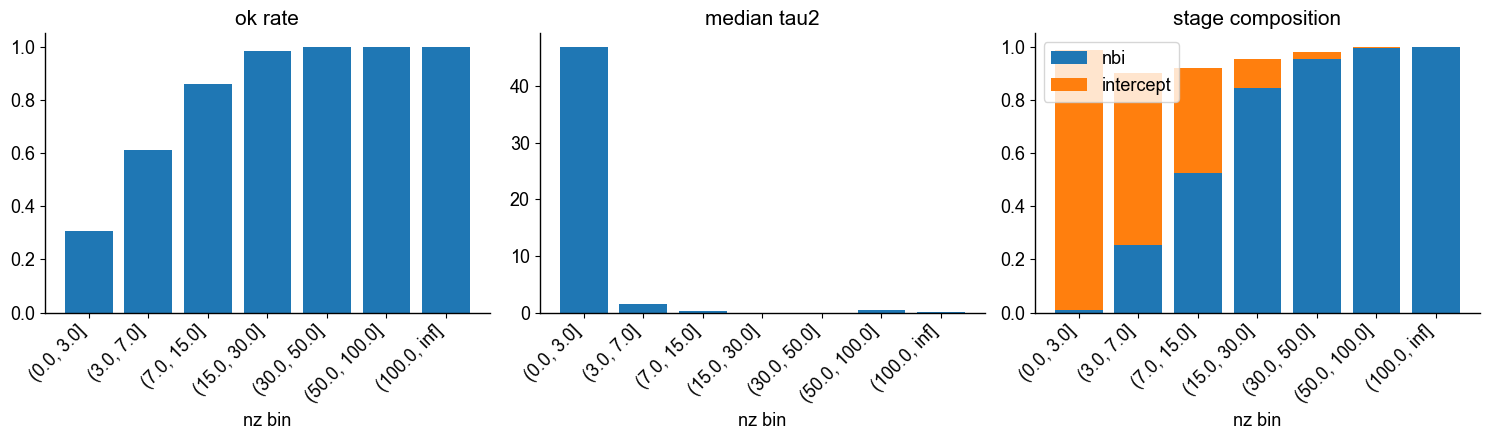

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
x = range(len(nz_stage_summary))
axes[0].bar(x, nz_stage_summary["ok_rate"]); axes[0].set(title="ok rate", xlabel="nz bin")
axes[1].bar(x, nz_stage_summary["tau2_median"]); axes[1].set(title="median tau2", xlabel="nz bin")
axes[2].bar(x, nz_stage_summary["pct_nbi"], label="nbi")
axes[2].bar(x, nz_stage_summary["pct_intercept"], bottom=nz_stage_summary["pct_nbi"], label="intercept")
axes[2].legend(); axes[2].set(title="stage composition", xlabel="nz bin")
for ax in axes:
    ax.set_xticks(list(x)); ax.set_xticklabels([str(b) for b in nz_stage_summary.index], rotation=45, ha="right")
fig.tight_layout()
plt.show()


## Summary numbers

In [14]:
summary_rows = [
    ("max_over_mean_p90 by stage", table["max_over_mean_p90"].to_dict()),
    ("nb_fixed median_std_ratio", stage_table.loc["nb_fixed", "median_std_ratio"] if "nb_fixed" in stage_table.index else None),
    ("std_z by stage", stage_table["std_z"].to_dict()),
    ("disp slope median", np.median(np.abs(disp_slopes))),
    ("mu slope median", np.median(np.abs(mu_slopes))),
    ("disp/mu slope median ratio", np.median(np.abs(disp_slopes)) / np.median(np.abs(mu_slopes))),
]
for name, val in summary_rows:
    print(name, "=", val)


max_over_mean_p90 by stage = {'intercept': 673.3122922711685, 'nb_fixed': 498.28364799598575, 'nbi': 176.58826357466077, 'nbi_disp_intercept': 336.27068607068605}
nb_fixed median_std_ratio = 5.9909145416800555
std_z by stage = {'intercept': 1.0061756372451782, 'nb_fixed': 1.0288289785385132, 'nbi': 1.0368024110794067, 'nbi_disp_intercept': 1.0084961652755737}
disp slope median = 0.04568791808575045
mu slope median = 0.1650238820834795
disp/mu slope median ratio = 0.27685640107920023
